In [72]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [73]:
df = pd.read_csv('Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


### Exploratory Data Analytics

Text(0.5, 1.0, 'radio Spend')

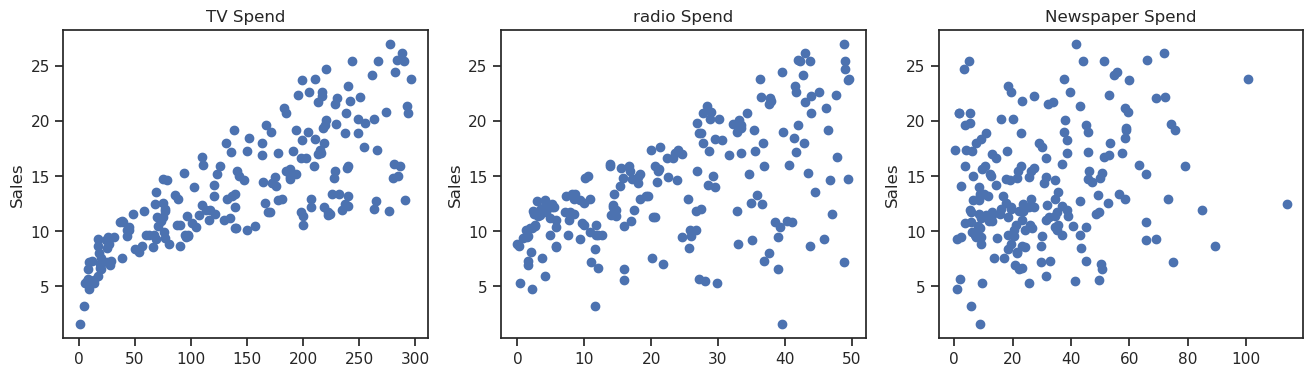

In [75]:
fig, axes = plt.subplots(1,3,figsize = (16,4))

axes[0].plot(df['TV'], df['sales'],'o')
axes[0].set_ylabel('Sales')
axes[0].set_title('TV Spend') 


axes[2].plot(df['newspaper'], df['sales'],'o')
axes[2].set_ylabel('Sales')
axes[2].set_title('Newspaper Spend')


axes[1].plot(df['radio'], df['sales'],'o')
axes[1].set_ylabel('Sales')
axes[1].set_title('radio Spend')



* There is strong +ve correlation on Tv spend, radio on sales.
* News spend have no correlation
* 

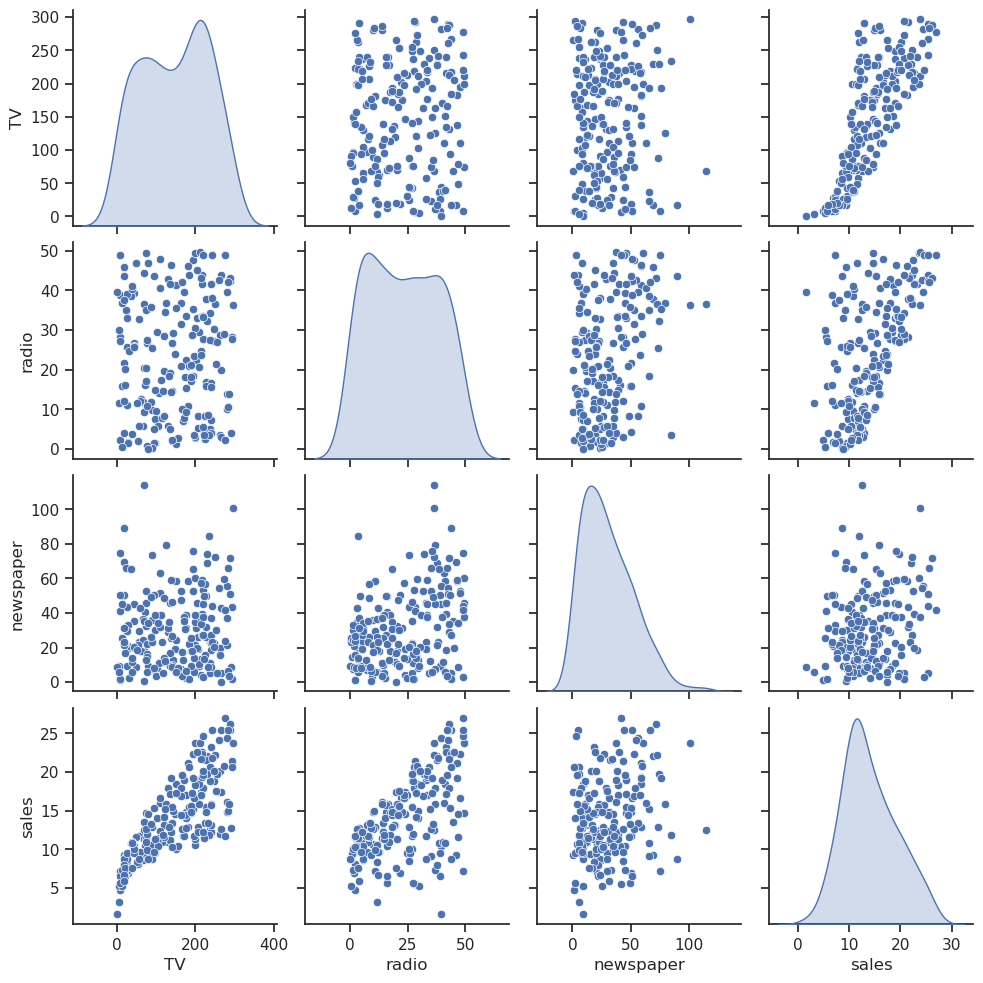

In [76]:
sns.pairplot(df, diag_kind = 'kde')

### Data cleaning commands

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


| Step | Action                                  | Purpose                          |
| ---- | --------------------------------------- | -------------------------------- |
| 1    | `df.info()` & `df.isnull().sum()`       | Diagnose issues: missing, types  |
| 2    | `dropna()` / `fillna()`                 | Clean or impute missing data     |
| 3    | `astype()` / `to_datetime()`            | Fix data types                   |
| 4    | String methods: `.str.strip()`, etc.    | Standardize text                 |
| 5    | `drop_duplicates()`                     | Remove repeats                   |
| 6    | Feature engineering                     | Prepare for analysis / modelling |
| 7    | Re-inspect with `df.info()` & `.head()` | Validate changes                 |


In [78]:
# If there is date time stord in string convert into date time format 
# df['date_col'] = pd.to_datetime(df['date_col'], errors='coerce')


In [79]:
# Show columns with missing values
df.isnull().sum()


TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [80]:
df = df.dropna(axis=0)  # drop rows with any nulls
df = df.dropna(axis=1)  # drop columns entirely null


In [81]:
# Check for duplicate row
df.duplicated().sum()


0

In [82]:
# Convert the column data type 
#df['num_col'] = df['num_col'].astype(float)  # or int


In [83]:
#Drop duplicates
df = df.drop_duplicates()


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


### Separate features (X) and Label(Y)

In [85]:
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [86]:
X = df.drop('sales', axis = 1)
X

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [87]:
y = df['sales']
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

### Train test split 

In [88]:
from sklearn.model_selection import train_test_split 

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state= 101)

In [90]:
X_train.shape # or use len(X_train)

(140, 3)

In [91]:
X_test.shape

(60, 3)

In [92]:
y_train.shape

(140,)

In [93]:
y_test.shape

(60,)

###  Create a Model

In [94]:
from sklearn.linear_model import LinearRegression

In [95]:
#help(LinearRegression)
model = LinearRegression() # we are creating an instance 

In [96]:
model.fit(X_train, y_train)

LinearRegression()

In [97]:
y_pred = model.predict(X_test)
y_pred

array([15.74131332, 19.61062568, 11.44888935, 17.00819787,  9.17285676,
        7.01248287, 20.28992463, 17.29953992,  9.77584467, 19.22194224,
       12.40503154, 13.89234998, 13.72541098, 21.28794031, 18.42456638,
        9.98198406, 15.55228966,  7.68913693,  7.55614992, 20.40311209,
        7.79215204, 18.24214098, 24.68631904, 22.82199068,  7.97962085,
       12.65207264, 21.46925937,  8.05228573, 12.42315981, 12.50719678,
       10.77757812, 19.24460093, 10.070269  ,  6.70779999, 17.31492147,
        7.76764327,  9.25393336,  8.27834697, 10.58105585, 10.63591128,
       13.01002595,  9.77192057, 10.21469861,  8.04572042, 11.5671075 ,
       10.08368001,  8.99806574, 16.25388914, 13.23942315, 20.81493419,
       12.49727439, 13.96615898, 17.56285075, 11.14537013, 12.56261468,
        5.50870279, 23.29465134, 12.62409688, 18.77399978, 15.18785675])

In [98]:
#X_test

In [99]:
y_test # Actual test result(True value)  

37     14.7
109    19.8
31     11.9
89     16.7
66      9.5
119     6.6
54     20.2
74     17.0
145    10.3
142    20.1
148    10.9
112    14.1
174    11.5
55     23.7
141    19.2
149    10.1
25     12.0
34      9.5
170     8.4
39     21.5
172     7.6
153    19.0
175    27.0
61     24.2
65      9.3
50     11.4
42     20.7
129     9.7
179    12.6
2       9.3
12      9.2
133    19.6
90     11.2
22      5.6
41     17.1
32      9.6
125    10.6
196     9.7
158     7.3
180    10.5
16     12.5
186    10.3
144    11.4
121     7.0
80     11.8
18     11.3
78      5.3
48     14.8
4      12.9
15     22.4
1      10.4
43     12.9
102    14.8
164    11.9
9      10.6
155     3.2
36     25.4
190    10.8
33     17.4
45     14.9
Name: sales, dtype: float64

### Performance metrics
* To check how our model performed
* Mean Absolute error
* mean squared error 
* Root mean square error : analogous to standard deviation. (Refer slides)
* What is the good value of RMSE? 
*     "It depends."
    There’s no absolute “good” or “bad” RMSE value. What is acceptable varies depending on:

    The scale of the target variable.

    The application domain.

    Whether the model is used for decision-making, automation, or just exploratory analysis.
| Use Case                                  | Acceptable RMSE?        | Reasoning                                          |
| ----------------------------------------- | ----------------------- | -------------------------------------------------- |
| **Predicting house prices** (in ₹ lakhs)  | RMSE = 2 → Acceptable   | If average house price is ₹50L, ±2L is small error |
| **Medical diagnosis**                     | RMSE = 1 → Risky        | Even small errors can mislead critical decisions   |
| **Physics simulation** (microscale)       | RMSE = 0.01 → High      | Needs very high accuracy                           |
| **E-commerce rating prediction** (1 to 5) | RMSE = 0.5 → Good       | Within half a star                                 |
| **Predicting age** (scale: 0–100)         | RMSE = 10 → Large error | That’s ±10 years                                   |
| **Daily temperature forecasting** (in °C) | RMSE = 1 → Acceptable   | Small enough for practical use                     |
  

## 📊 Anscombe's Quartet

**Anscombe's Quartet** is a set of four datasets created by statistician **Francis Anscombe** in 1973 to demonstrate the importance of **visualizing data** before analyzing it statistically.

---

### 🔍 What Makes It Special?

Each of the four datasets has:

- The **same mean** for both `x` and `y`
- The **same variance** for both `x` and `y`
- The **same correlation coefficient** between `x` and `y`
- The **same linear regression line** (slope and intercept)

> Yet, the **visualizations are dramatically different**!

---

### 📐 Summary Statistics (Identical for All 4 Sets)

| Statistic              | Value        |
|------------------------|--------------|
| Mean of `x`            | 9.0          |
| Mean of `y`            | 7.5          |
| Correlation (r)        | ~0.816       |
| Linear regression line | y = 3 + 0.5x |

---

### 📈 Visual Interpretation

- **Dataset I**: Appears as a classic linear relationship.
- **Dataset II**: Shows a clear non-linear (curved) relationship.
- **Dataset III**: Has a linear trend but with a significant outlier.
- **Dataset IV**: Shows one influential point that drives the regression line.

---

### 🧠 Key Takeaway

> **"Summary statistics can be misleading. Always visualize your data!"**

Anscombe’s Quartet teaches us that:
- Data visualization is essential.
- Outliers and non-linearity can hide behind identical statistics.
- Exploratory Data Analysis (EDA) should never be skipped.

---

### 💡 Applications

- Teaching concepts in statistics and data science
- Demonstrating the limitations of relying solely on descriptive statistics
- Encouraging deeper data exploration and critical thinking


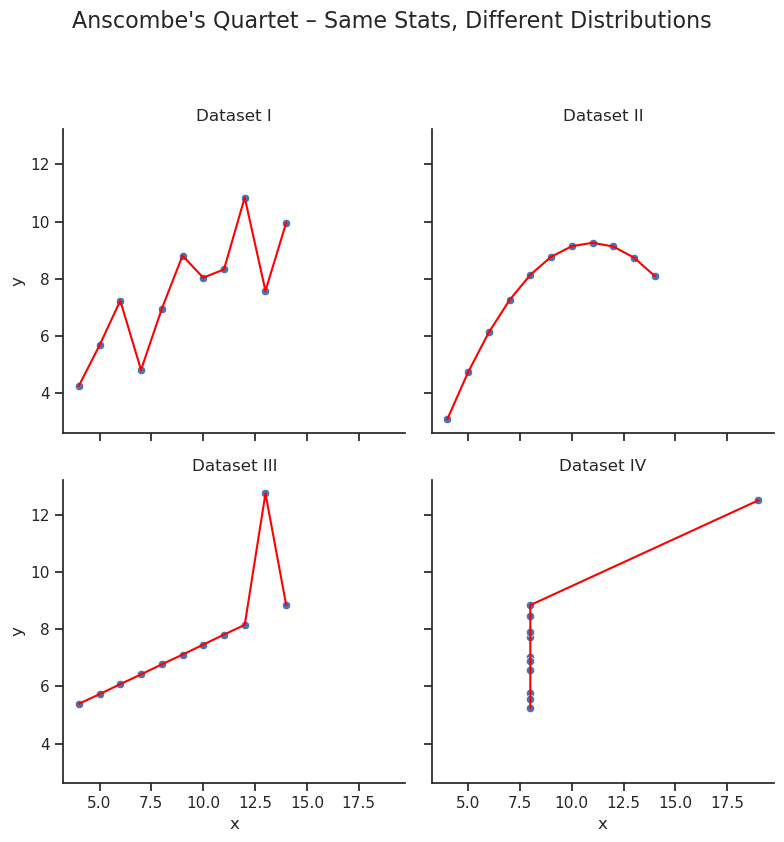

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load Anscombe's dataset
df_anscombe = sns.load_dataset("anscombe")

# Set visual style
sns.set(style="ticks")

# Create FacetGrid to plot all 4 datasets
g = sns.FacetGrid(df_anscombe, col="dataset", col_wrap=2, height=4, aspect=1)
g.map_dataframe(sns.scatterplot, x="x", y="y")
g.map_dataframe(sns.lineplot, x="x", y="y", color="red", estimator=None)

# Add titles and layout
g.set_titles(col_template="Dataset {col_name}")
g.set_axis_labels("x", "y")
plt.suptitle("Anscombe's Quartet – Same Stats, Different Distributions", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()


#### Note: So linear Regression wont be a good choice for all data set

### ## ⚠️ When Linear Regression Is Not a Good Choice

Linear regression is a simple and widely used model, but it's **not always appropriate**. Here are key reasons why it can fail:

---

### ❌ Situations Where Linear Regression Fails

1. **Non-linear Relationships**  
   - Linear regression assumes a straight-line relationship between variables.
   - If the data follows a curve (e.g., quadratic, exponential), a linear model will underperform.
   - 👉 *Example: Anscombe's Dataset II shows a curved trend that a straight line cannot capture.*

2. **Outliers and Influential Points**  
   - A single extreme point can heavily influence the slope of the regression line.
   - 👉 *Dataset III and IV in Anscombe's Quartet demonstrate this.*

3. **Heteroscedasticity**  
   - Linear regression assumes the residuals (errors) have constant variance.
   - If residuals fan out or shrink with increasing `x`, the assumption is violated.

4. **Non-normal Residuals**  
   - Linear regression assumes the residuals are normally distributed for valid inference (e.g., confidence intervals).

5. **Multicollinearity (in multiple regression)**  
   - When predictor variables are highly correlated, the model becomes unstable and coefficients lose meaning.

---

### ✅ When Linear Regression Works Well

- The relationship between variables is approximately **linear**
- There are **no strong outliers**
- Residuals are **homoscedastic** (equal variance)
- Residuals are **normally distributed**

---

### 🧠 Key Takeaway

> **Don't blindly apply linear regression. Always visualize your data and check its assumptions.**

If the data doesn’t meet the assumptions, consider:
- Non-linear regression
- Polynomial regression
- Tree-based models (e.g., decision trees, random forests)
- Transforming variables (e.g., log, sqrt)

---

### 📌 Related Tip

Try plotting:
```python
sns.residplot(x='x', y='y', data=your_data)


## 📉 Understanding Residual Errors in Linear Regression

In regression, it's important that **residuals** — the differences between actual and predicted values — meet certain assumptions to ensure the model is reliable.

---

### ✅ What Are Residuals?

\[
\text{Residual} = y_{\text{actual}} - y_{\text{predicted}}
\]

Residuals are the errors made by the model when predicting outcomes.

---

### 🧠 Why Should Residuals Be **Random** and **Normally Distributed**?

These are **key assumptions** for linear regression to work properly.

---

### 1. ✅ **Random Residuals**

- Residuals should be randomly scattered around zero.
- No patterns, curves, or funnel shapes in the residual plot.
- If residuals show structure, it indicates:
  - Non-linear relationships
  - Model is missing important variables
  - Heteroscedasticity (variance of error changes with input)

> 🟢 **Good sign**: Residual plot looks like a random cloud of points.

---

### 2. ✅ **Normally Distributed Residuals**

- Residuals should follow a **normal distribution**, centered at 0.
- This is important for:
  - Calculating **confidence intervals**
  - Making **hypothesis tests** on model coefficients

You can check this using:
- **Histogram** of residuals
- **Q-Q plot** (quantile-quantile plot)

> 🟢 **Good sign**: Histogram looks like a bell curve, Q-Q plot falls close to the diagonal line.

---

### 📊 Example Python Code to Check Residuals

```python
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Assuming 'residuals' is a NumPy array or list of residual values

# Histogram
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.show()

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()


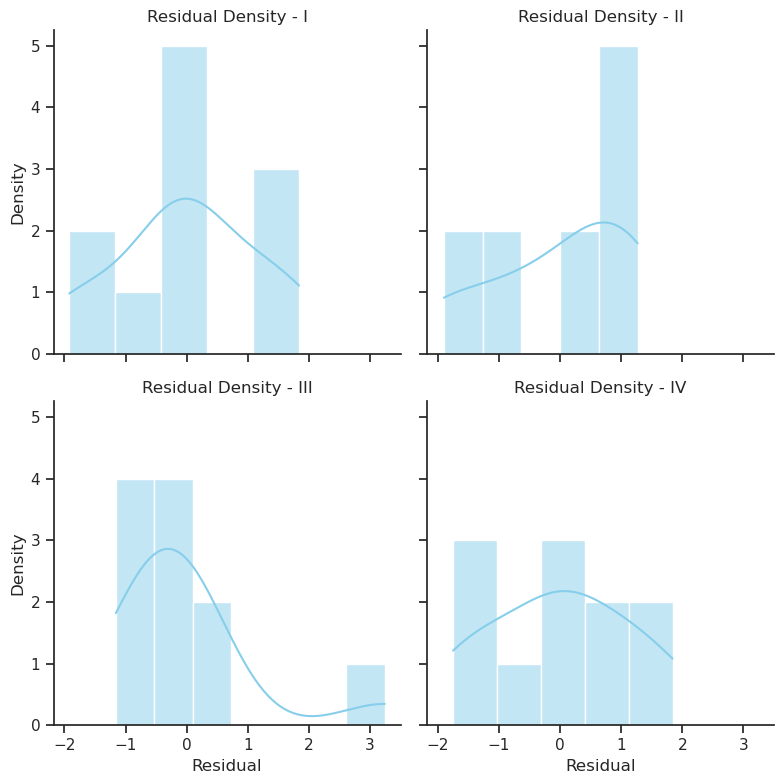

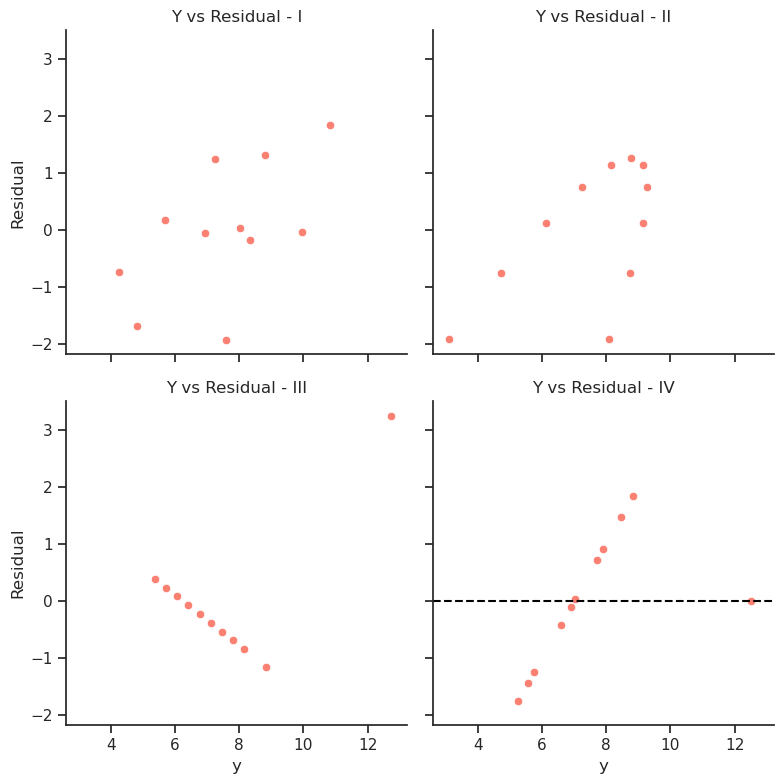

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Load Anscombe's dataset
df_anscombe = sns.load_dataset("anscombe")

# Container to store residuals with dataset labels
residual_data = []

# Loop over each dataset
for name, group in df_anscombe.groupby("dataset"):
    x_ = group["x"]
    y_ = group["y"]
    
    # Add constant for intercept (required by statsmodels)
    X_ = sm.add_constant(x_)
    
    # Fit linear regression model
    model_ = sm.OLS(y_, X_).fit()
    y_pred_ = model_.predict(X_)
    
    # Compute residuals
    residuals = y_ - y_pred_
    
    # Store in dataframe for plotting
    df_temp = pd.DataFrame({
        "x": x_,
        "y": y_,
        "y_pred": y_pred_,
        "residual": residuals,
        "dataset": name
    })
    residual_data.append(df_temp)

# Concatenate all datasets
df_residuals = pd.concat(residual_data)

# --- Plot 1: Residuals vs Density --- ( This should be normally distributed and centered around 0, for linear regression if the data is fit for linear regression.) 
g1 = sns.FacetGrid(df_residuals, col="dataset", col_wrap=2, height=4, aspect=1)
g1.map_dataframe(sns.histplot, x="residual", kde=True, color="skyblue")
g1.set_titles(col_template="Residual Density - {col_name}")
g1.set_axis_labels("Residual", "Density")
plt.tight_layout()
plt.show()

# --- Plot 2: y vs Residuals ---( If this plot have any pattern then the data is not fit for Linear regression )
g2 = sns.FacetGrid(df_residuals, col="dataset", col_wrap=2, height=4, aspect=1)
g2.map_dataframe(sns.scatterplot, x="y", y="residual", color="salmon")
g2.set_titles(col_template="Y vs Residual - {col_name}")
g2.set_axis_labels("y", "Residual")
plt.axhline(0, ls='--', color='black')  # Add reference line at 0
plt.tight_layout()
plt.show()


* **Note**:In data set 2, 3, 4 y vs residual plot we see a pattern hence this data set is not good for linear regression

### Performance metrics

In [129]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [130]:

MAE = mean_absolute_error(y_test, y_pred)
MAE

1.2137457736144805

In [131]:
MSQ = mean_squared_error(y_test, y_pred) # like a varience gives different scale. 
MSQ

2.298716697886379

In [132]:
RMSE = np.sqrt(MSQ) # like standard deviation of prediction (on same scale) 
RMSE

1.5161519375993882

In [136]:
# R - squared --> How well your model explains the variablity in the target variable(-inf to 1)
# 1 --> means perfect prediction y-yhat = = 
# 0 ----> model does no better than mean 
# Negative --> model is worse than predicting the mean 
r2_score(y_test, y_pred) # It should be as close to 1

0.9185780903322445

### 📊 Regression Evaluation Metrics

---

#### ✅ 1. R² (R-squared or Coefficient of Determination)

- Measures how well the model explains the variance in the data.
- **Range**:  
  - \( R^2 = 1 \): Perfect prediction  
  - \( R^2 = 0 \): Model predicts no better than the mean  
  - \( R^2 < 0 \): Model performs worse than the mean

**Formula**:
\[
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
\]

---

#### ❌ 2. MSE (Mean Squared Error)

- Average of the squared differences between actual and predicted values.
- Sensitive to large errors.

**Formula**:
\[
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
\]

---

#### 📉 3. RMSE (Root Mean Squared Error)

- Square root of MSE.
- Gives error in the same unit as the target variable.
- Penalizes large errors more than MAE.

**Formula**:
\[
\text{RMSE} = \sqrt{\text{MSE}}
\]

---

#### ➕ 4. MAE (Mean Absolute Error)

- Average of the absolute differences between actual and predicted values.
- Less sensitive to outliers than MSE/RMSE.

**Formula**:
\[
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
\]

---

### 📌 Summary Table

| Metric  | Sensitive to Outliers? | Units           | Range             | Goal         |
|---------|------------------------|------------------|--------------------|--------------|
| R²      | No                     | Unitless         | \(-\infty\) to 1    | Closer to 1  |
| MSE     | Yes                    | Squared units    | \([0, \infty)\)     | Closer to 0  |
| RMSE    | Yes                    | Same as target   | \([0, \infty)\)     | Closer to 0  |
| MAE     | No                     | Same as target   | \([0, \infty)\)     | Closer to 0  |


### 📊 Understanding MSE vs Variance

---

#### ✅ MSE (Mean Squared Error)

- Measures the **average squared difference** between actual values (\( y \)) and predicted values (\( \hat{y} \)).
- It tells you **how far off** your model's predictions are.
- **Lower MSE** means better predictions.

**Formula**:
\[
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\]

---

#### 📈 Variance of Target (\( y \))

- Measures the **natural spread** or **variability** of the true target values from their mean.
- It tells you how much the actual data fluctuates on its own.

**Formula**:
\[
\text{Var}(y) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y})^2
\]

---

### 🔁 Key Differences

| Concept     | MSE                                      | Variance of \( y \)                   |
|-------------|-------------------------------------------|----------------------------------------|
| Measures    | Error between predictions and true values | Spread of actual target values         |
| Uses        | Model performance evaluation              | Understanding data distribution        |
| Based on    | \( y_i - \hat{y}_i \)                     | \( y_i - \bar{y} \)                     |
| Used in     | Loss functions, R²                        | R² (as denominator), data analysis     |

---

### 🧠 Connection to R² (R-squared)

R² compares how much **better your model is** than just predicting the mean of \( y \):

\[
R^2 = 1 - \frac{\text{MSE}}{\text{Var}(y)}
\]

- If **MSE = 0** → Perfect prediction → \( R^2 = 1 \)
- If **MSE ≈ Var(y)** → Model is no better than guessing the mean → \( R^2 ≈ 0 \)

---

### 🎯 Summary

- **MSE**: "How wrong is the model?"
- **Variance**: "How much does the data naturally vary?"
- **R²**: "How much of that variation did the model capture?"



In [106]:
df['sales'].mean() #avg sales value

14.022500000000003

In [107]:
df['sales'].max()

27.0

In [108]:
df['sales'].min()

1.6

In [109]:
df['sales'].median()

12.9

| Metric   | Meaning                               | Ideal Value |
| -------- | ------------------------------------- | ----------- |
| **MAE**  | Avg. absolute error                   | Close to 0  |
| **RMSE** | Penalizes larger errors more than MAE | Close to 0  |
| **R²**   | % of variance explained by the model  | Close to 1  |


###  Plotting the residual

In [110]:
y_test - y_pred

37    -1.041313
109    0.189374
31     0.451111
89    -0.308198
66     0.327143
119   -0.412483
54    -0.089925
74    -0.299540
145    0.524155
142    0.878058
148   -1.505032
112    0.207650
174   -2.225411
55     2.412060
141    0.775434
149    0.118016
25    -3.552290
34     1.810863
170    0.843850
39     1.096888
172   -0.192152
153    0.757859
175    2.313681
61     1.378009
65     1.320379
50    -1.252073
42    -0.769259
129    1.647714
179    0.176840
2     -3.207197
12    -1.577578
133    0.355399
90     1.129731
22    -1.107800
41    -0.214921
32     1.832357
125    1.346067
196    1.421653
158   -3.281056
180   -0.135911
16    -0.510026
186    0.528079
144    1.185301
121   -1.045720
80     0.232893
18     1.216320
78    -3.698066
48    -1.453889
4     -0.339423
15     1.585066
1     -2.097274
43    -1.066159
102   -2.762851
164    0.754630
9     -1.962615
155   -2.308703
36     2.105349
190   -1.824097
33    -1.374000
45    -0.287857
Name: sales, dtype: float64

In [111]:
test_res = y_test - y_pred # we should get as random as possible for the data to be good for linear regression

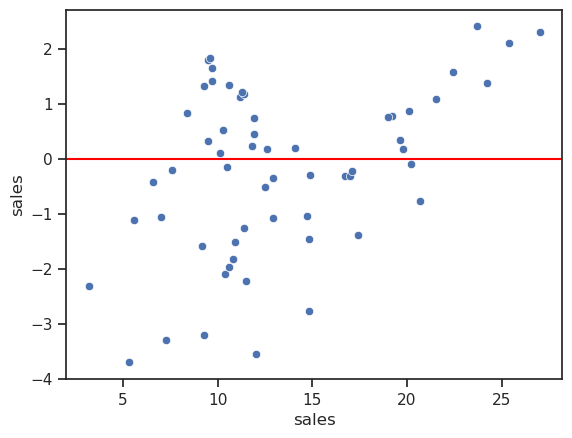

In [112]:
sns.scatterplot(x = y_test, y = test_res)
plt.axhline(y = 0, c = 'red')

* we can do linear regression, but RMSE is not goo it is high. 

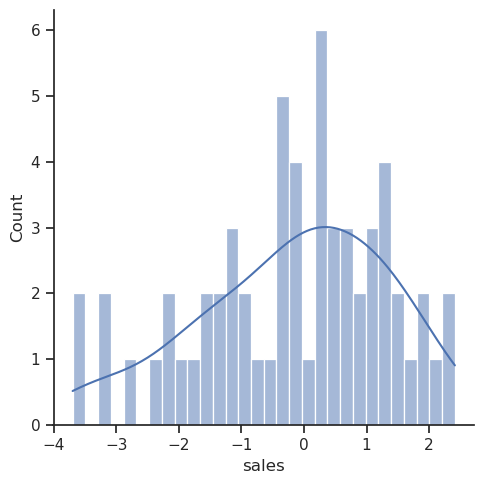

In [113]:
# Distribution plot 
sns.displot(test_res, bins = 30, kde = True)

### Retrain the Model on Full data
* that is Iam satisfied with model preiction, So Iam retraining the model with full data. 

In [114]:
final_model = LinearRegression()

In [115]:
final_model.fit(X,y)

LinearRegression()

In [116]:
final_model.predict(X)
#final_model.predict(X).shape()


array([20.52397441, 12.33785482, 12.30767078, 17.59782951, 13.18867186,
       12.47834763, 11.72975995, 12.12295317,  3.72734086, 12.55084872,
        7.0322992 , 17.28512918, 10.57712073,  8.82630048, 18.43436638,
       20.81929952, 12.82365674, 23.22495716,  9.95168206, 14.16607293,
       18.10076728, 14.7405382 ,  6.4891503 , 16.5459329 ,  8.14651887,
       15.6100386 , 14.98951429, 17.05167344, 19.41053803,  9.14402389,
       21.6339338 , 11.3460929 ,  7.63888314, 18.86426829,  7.57483051,
       17.00682618, 23.40590052, 15.62347779,  9.90868103, 20.44761039,
       16.37766467, 17.2959832 , 21.59580326, 13.96385684,  8.88787996,
       15.16152314,  8.87338673, 21.7226299 , 16.26362018,  8.1681656 ,
       12.63121132,  9.33981296, 20.66297563, 19.94469957, 20.37443008,
       21.2926106 ,  8.52771254, 12.77458802, 21.89805198, 18.13348698,
        5.74215558, 22.89067208, 16.78426073, 13.21069202, 16.97773556,
        7.84904532,  9.01603163, 12.0370073 , 18.97657924, 21.10

In [117]:
y_Hat = final_model.predict(X)


Text(0.5, 1.0, 'Newspaper spend')

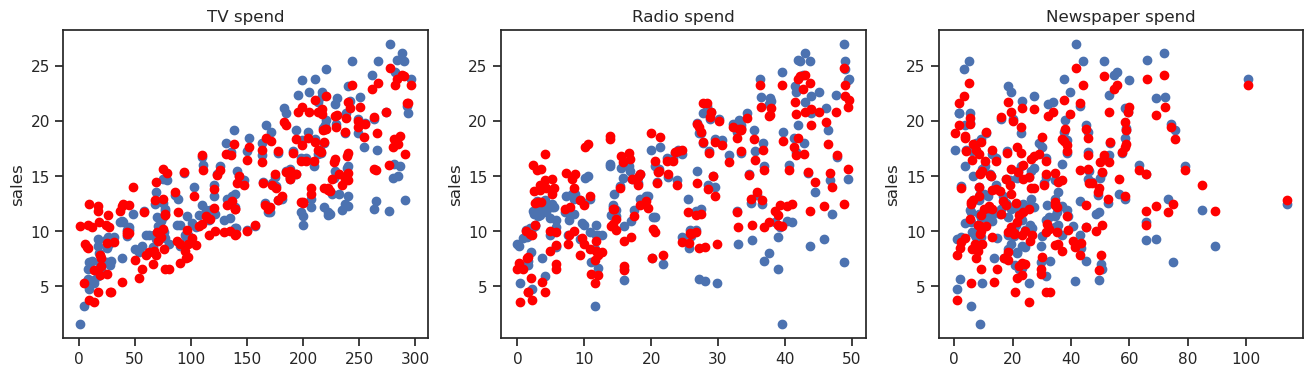

In [118]:
fig, axes = plt.subplots(1,3,figsize = (16,4))
axes[0].plot(df['TV'],df['sales'],'o')
axes[0].plot(df['TV'], y_Hat, 'o', color = 'red')
axes[0].set_ylabel('sales')
axes[0].set_title('TV spend')

axes[1].plot(df['radio'],df['sales'],'o')
axes[1].plot(df['radio'], y_Hat, 'o', color = 'red')
axes[1].set_ylabel('sales')
axes[1].set_title('Radio spend')

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].plot(df['newspaper'], y_Hat, 'o', color = 'red')
axes[2].set_ylabel('sales')
axes[2].set_title('Newspaper spend')




### Coefficient 

In [119]:
final_model.coef_ # coeff of all my features : beta 

array([ 0.04576465,  0.18853002, -0.00103749])

* Here coeff of newspaper is close to zero. Hence it have less contribution on sales.
* But Spending on radio matters a lot. 

In [120]:
df.corr()['sales'] # This also cofirms TV hasgood corelation on sales. 

TV           0.782224
radio        0.576223
newspaper    0.228299
sales        1.000000
Name: sales, dtype: float64

### Prediction on new data

In [121]:
X_test.shape

(60, 3)

In [122]:
final_model.predict([[149, 22, 12], [10,4,10000]])  # [[TV, Radio, newspaper]]

/home/saji/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13.893032  , -6.22427453])

### Model persistence (Saving and Loading a Model)

In [123]:
from joblib import dump, load 

In [124]:
dump(final_model, 'sales_model.joblib') # Saves the model in the local system. 

['sales_model.joblib']

###  Loading the sales model

In [125]:
from joblib import load 

In [126]:
loaded_model = load('sales_model.joblib')

In [127]:
tv_spend = 123
radio_spend = 100 
newspaper_spend = 50

In [128]:
loaded_model.predict([[tv_spend, radio_spend, newspaper_spend]])

/home/saji/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([27.3690678])